## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Dev\causal(2026)\.venv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [6]:
# 구글 주식 데이터 로딩
goog = yf.download("INTC", start="2020-01-01", end="2026-04-28")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2020-01-02,53.666470,53.781142,53.119574,53.137216,18056000
2020-01-03,53.013725,53.542982,52.757921,52.757921,15293900
2020-01-06,52.863766,53.101931,52.334512,52.563854,17755200
2020-01-07,51.981667,52.749085,51.946382,52.731443,21876100
2020-01-08,52.016949,52.325679,51.620007,51.946380,23133500


In [8]:
# [+] 종가(Close) 데이터만 사용하기
goog = goog['Close']
goog

Ticker,INTC
Date,
2020-01-02,53.666470
2020-01-03,53.013725
2020-01-06,52.863766
2020-01-07,51.981667
2020-01-08,52.016949
...,...
2026-04-21,66.260002
2026-04-22,65.269997
2026-04-23,66.779999


<Axes: xlabel='Date'>

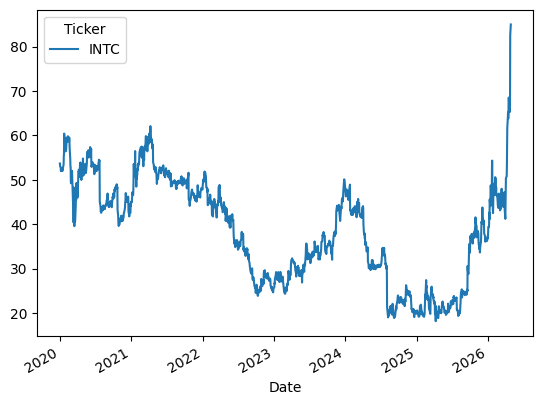

In [9]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [10]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME').mean()
goog_downsampled

Ticker,INTC
Date,
2020-01-31,54.564940
2020-02-29,56.958799
2020-03-31,46.209498
2020-04-30,51.777564
2020-05-31,53.618139
...,...
2025-12-31,38.544545
2026-01-31,45.798000
2026-02-28,46.973158


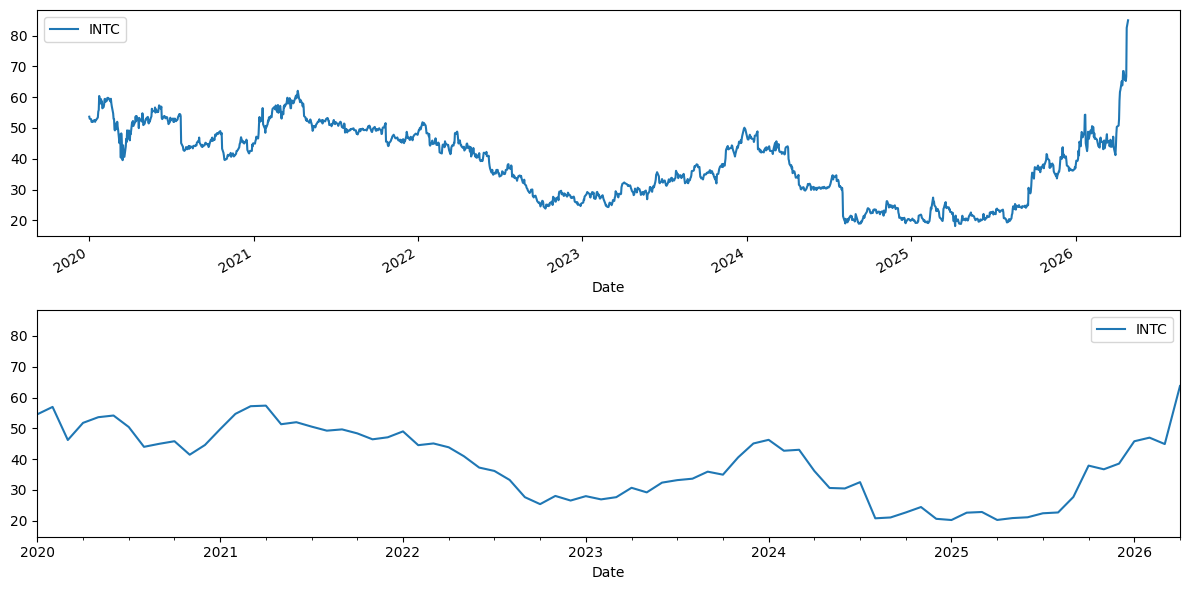

In [11]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Ticker           INTC
Date                 
2020-01-31  56.392132
2020-02-29        NaN
2020-03-31  47.973907
2020-04-30  53.168423
2020-05-31        NaN
...               ...
2025-11-30        NaN
2025-12-31  36.900002
2026-01-31        NaN
2026-02-28        NaN
2026-03-31  44.130001

[75 rows x 1 columns]


<Axes: xlabel='Date'>

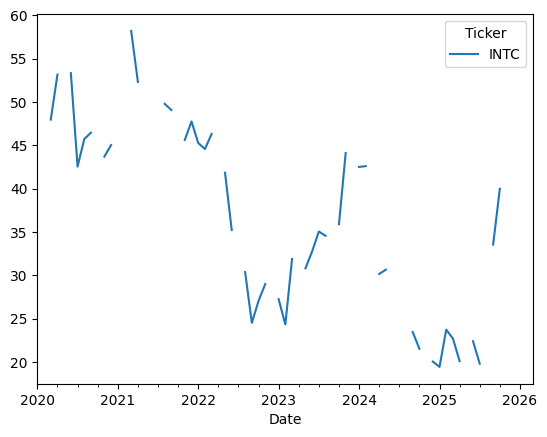

In [12]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [13]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').mean()
print(goog_upsampled)

Ticker                    INTC
Date                          
2020-01-02 00:00:00  53.666470
2020-01-02 12:00:00        NaN
2020-01-03 00:00:00  53.013725
2020-01-03 12:00:00        NaN
2020-01-04 00:00:00        NaN
...                        ...
2026-04-25 00:00:00        NaN
2026-04-25 12:00:00        NaN
2026-04-26 00:00:00        NaN
2026-04-26 12:00:00        NaN
2026-04-27 00:00:00  84.989998

[4615 rows x 1 columns]


#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [14]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods = -900)
goog_shifted

Ticker,INTC
Date,
2020-01-02,35.084869
2020-01-03,33.703033
2020-01-06,34.173443
2020-01-07,34.561951
2020-01-08,34.650471
...,...
2026-04-21,NaN
2026-04-22,NaN
2026-04-23,NaN


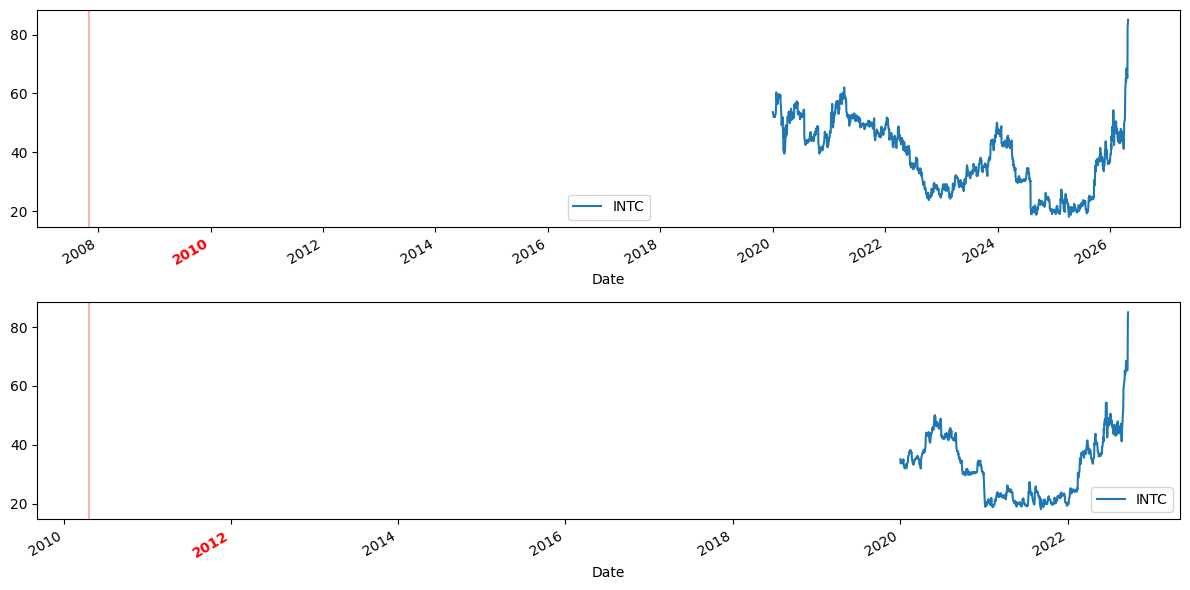

In [15]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [16]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods = 1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Ticker,INTC
Date,
2020-01-02,NaN
2020-01-03,-0.012163
2020-01-06,-0.002829
2020-01-07,-0.016686
2020-01-08,0.000679
...,...
2026-04-21,0.008524
2026-04-22,-0.014941
2026-04-23,0.023135


Ticker           INTC
Date                 
2020-01-02        NaN
2020-01-03  -0.652744
2020-01-06  -0.149960
2020-01-07  -0.882099
2020-01-08   0.035282
...               ...
2026-04-21   0.560005
2026-04-22  -0.990005
2026-04-23   1.510002
2026-04-24  15.760002
2026-04-27   2.449997

[1587 rows x 1 columns]


<Axes: xlabel='Date'>

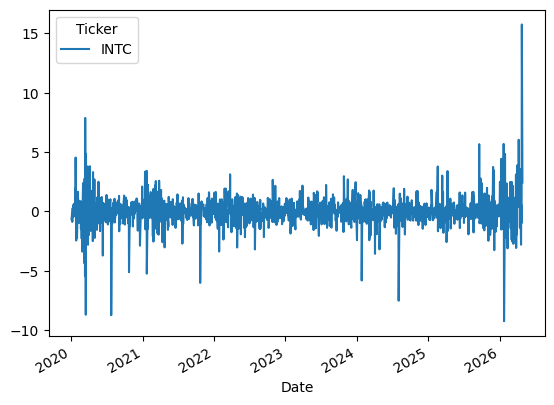

In [17]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

Rolling [window=365,center=False,method=single]


<Axes: xlabel='Date'>

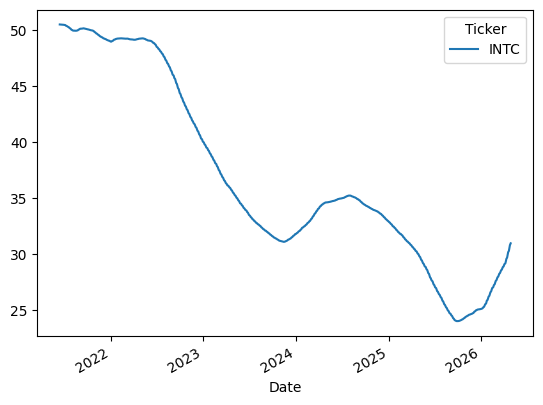

In [18]:
# [+] 365일 단위 윈도잉
goog_rolled = goog.rolling(365)
print(goog_rolled)

goog_rolled.mean().plot()

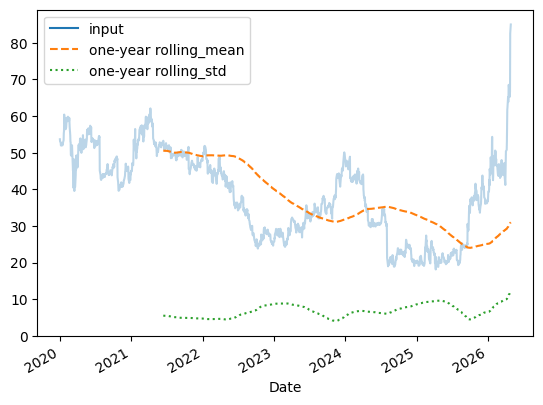

In [19]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)